# Лабораторная работа 12

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание задачи GAN (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. Для чего нужны генеративно‑состязательные сети (GAN) и чем их цель отличается от классической задачи классификации.  
2. Как вы интуитивно представляете «игру» генератора и дискриминатора: кто что пытается сделать и почему это неустойчивая задача.  
3. Каких визуальных артефактов вы ожидаете от **простого** Vanilla GAN на MNIST (размытость, странные гибриды цифр и т.п.).

Пишите своими словами, как если бы объясняли задачу одногруппнику.


In [3]:
intro_text = """1. GAN нужны для генерации новых данных, которые похожи на реальные, например новых картинок цифр, лиц или объектов. В классической классификации модель только определяет, к какому классу относится уже существующее изображение. В GAN модель учится самому распределению данных, чтобы уметь придумывать новые примеры. То есть классификатор отвечает на вопрос что это за картинка, а GAN отвечает на вопрос как нарисовать картинку, похожую на те, что были в обучении.
2. Генератор берет случайный шум и пытается превратить его в картинку, которая будет максимально похожа на настоящую. Дискриминатор получает и реальные, и сгенерированные изображения и учится отличать одно от другого. Генератор стремится обмануть дискриминатор, а дискриминатор стремится этот обман поймать. Задача получается неустойчивой, потому что иногда один из них сильно выигрывает, и второй почти не получает полезного сигнала для обучения.
3. От простого Vanilla GAN на MNIST я ожидаю, что не все цифры будут выглядеть аккуратно. Часто будут размытые контуры, нечеткие линии и толстые или слишком рваные цифры. Возможно появление гибридов, которые похожи сразу на две цифры, например что‑то между 3 и 8 или 4 и 9. На ранних этапах обучения часть картинок может вообще напоминать кляксы или шум, а не узнаваемые цифры."""
print(intro_text)

1. GAN нужны для генерации новых данных, которые похожи на реальные, например новых картинок цифр, лиц или объектов. В классической классификации модель только определяет, к какому классу относится уже существующее изображение. В GAN модель учится самому распределению данных, чтобы уметь придумывать новые примеры. То есть классификатор отвечает на вопрос что это за картинка, а GAN отвечает на вопрос как нарисовать картинку, похожую на те, что были в обучении.
2. Генератор берет случайный шум и пытается превратить его в картинку, которая будет максимально похожа на настоящую. Дискриминатор получает и реальные, и сгенерированные изображения и учится отличать одно от другого. Генератор стремится обмануть дискриминатор, а дискриминатор стремится этот обман поймать. Задача получается неустойчивой, потому что иногда один из них сильно выигрывает, и второй почти не получает полезного сигнала для обучения.
3. От простого Vanilla GAN на MNIST я ожидаю, что не все цифры будут выглядеть аккуратно

## 2. Импорт, настройки и данные (MNIST)


In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 11  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

# каталог для возможного сохранения картинок
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # пиксели в [-1, 1]
])

batch_size = 128

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))

Устройство: cpu
MY_SEED = 11


100%|██████████| 9.91M/9.91M [00:00<00:00, 51.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.62MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.65MB/s]

Размер train: 60000


Посмотрим на несколько реальных изображений, которые GAN должен научиться имитировать.


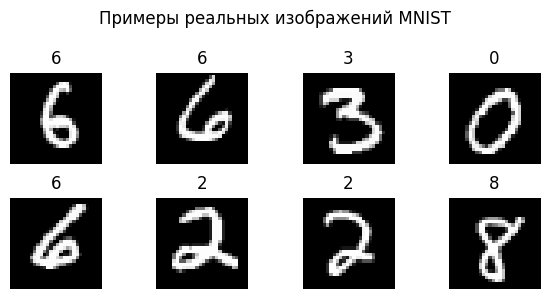

In [5]:
real_images, real_labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры реальных изображений MNIST")
plt.tight_layout()
plt.show()

### Мини‑комментарий по данным

Кратко (3–5 предложений) опишите:
- насколько, на ваш взгляд, легко/сложно генератору научиться имитировать такие цифры;  
- какие особенности рукописных цифр могут затруднить генерацию (разные стили, толщина линий и т.п.).


In [14]:
data_comment = """Для генератора такие картинки не совсем простые, хотя цифры выглядят довольно крупно и контрастно. Цифры 6, 8 и 2 неровные, линии местами дрожат и имеют разную толщину, это усложняет задачу.
У разных людей разный почерк, поэтому форма одной и той же цифры заметно меняется.Генератору нужно научиться и общей форме цифр, и таким мелким особенностям, как наклон, кривизна линий и положение цифры внутри квадрата. Из‑за этого он может путаться и иногда выдавать промежуточные или смазанные варианты."""
print(data_comment)

Для генератора такие картинки не совсем простые, хотя цифры выглядят довольно крупно и контрастно. Цифры 6, 8 и 2 неровные, линии местами дрожат и имеют разную толщину, это усложняет задачу. 
У разных людей разный почерк, поэтому форма одной и той же цифры заметно меняется.Генератору нужно научиться и общей форме цифр, и таким мелким особенностям, как наклон, кривизна линий и положение цифры внутри квадрата. Из‑за этого он может путаться и иногда выдавать промежуточные или смазанные варианты.


## 3. Архитектура генератора и дискриминатора

Используем классический Vanilla GAN с полносвязными сетями:
- Генератор: принимает случайный шум `z` размерности 100 и выдаёт изображение 28×28 (через `tanh`, в диапазоне [-1, 1]);  
- Дискриминатор: принимает изображение 28×28 и выдаёт вероятность того, что оно "реальное".


In [6]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=2048, bias=True)
    (7): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Linear(in_features=2048, out_features=1024, bias=True)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
    (12): Linear(in_features=1024, out_features=784, bias=True)
    (13): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatte

### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:
- почему в генераторе используется `tanh` на выходе и совместим ли он с нормализацией входных данных;  
- зачем в дискриминаторе используется `LeakyReLU`, а не обычный `ReLU`.


In [13]:
arch_comment = """1. В генераторе используют функцию tanh, потому что она дает значения от -1 до 1. Такие же границы у картинок MNIST после нормализации, поэтому выход генератора хорошо совпадает с диапазоном реальных данных. Дискриминатору тогда проще сравнивать реальные и сгенерированные изображения.
2. В дискриминаторе берут LeakyReLU, чтобы нейроны не умирали при отрицательных значениях. Эта функция оставляет небольшой отрицательный градиент и помогает слоям продолжать обучаться, что делает обучение более устойчивым."""
print(arch_comment)

1. В генераторе используют функцию tanh, потому что она дает значения от -1 до 1. Такие же границы у картинок MNIST после нормализации, поэтому выход генератора хорошо совпадает с диапазоном реальных данных. Дискриминатору тогда проще сравнивать реальные и сгенерированные изображения.
2. В дискриминаторе берут LeakyReLU, чтобы нейроны не умирали при отрицательных значениях. Эта функция оставляет небольшой отрицательный градиент и помогает слоям продолжать обучаться, что делает обучение более устойчивым.


## 4. Функция потерь, оптимизаторы и фиксированный шум

Используем бинарную кросс‑энтропию и два оптимизатора Adam (для G и D).


In [9]:
criterion = nn.BCELoss()

lr_G = 2e-4
lr_D = 1e-4
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 100])


## 5. Цикл обучения GAN с журналированием лоссов

На каждой итерации:

1. Обновляем дискриминатор: считаем лосс на реальных и сгенерированных изображениях.  
2. Обновляем генератор: генерируем фейки и стараемся заставить дискриминатор считать их реальными.


Эпоха 1/30 | loss_G=0.7433, loss_D=1.3364


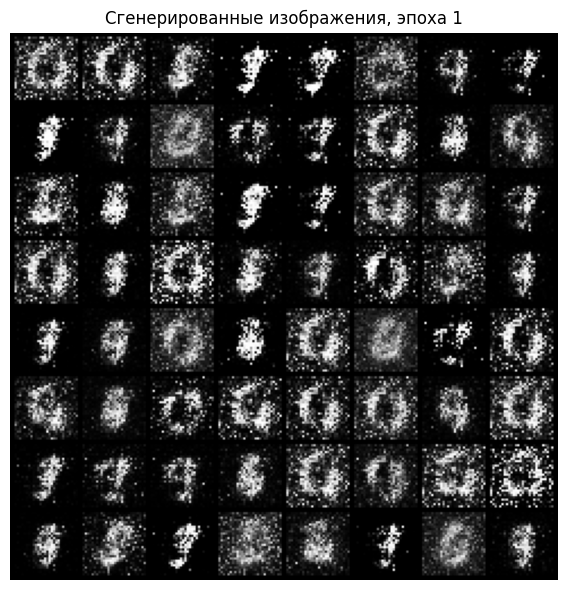

Эпоха 2/30 | loss_G=0.9136, loss_D=1.2946
Эпоха 3/30 | loss_G=1.0077, loss_D=1.2524
Эпоха 4/30 | loss_G=1.0935, loss_D=1.1992
Эпоха 5/30 | loss_G=1.0578, loss_D=1.1972


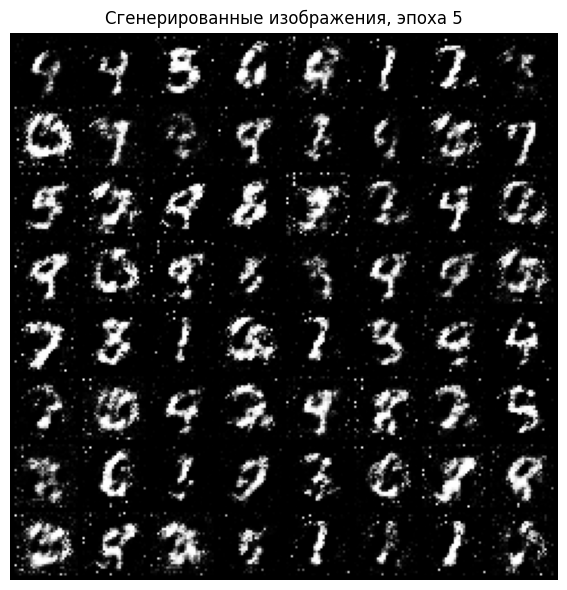

Эпоха 6/30 | loss_G=1.0305, loss_D=1.2075
Эпоха 7/30 | loss_G=0.9729, loss_D=1.2350
Эпоха 8/30 | loss_G=0.9416, loss_D=1.2468
Эпоха 9/30 | loss_G=0.9396, loss_D=1.2503
Эпоха 10/30 | loss_G=0.9262, loss_D=1.2575


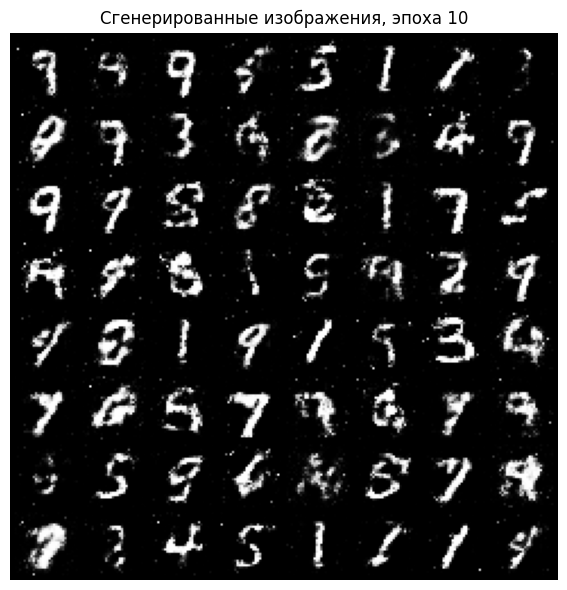

Эпоха 11/30 | loss_G=0.8875, loss_D=1.2795
Эпоха 12/30 | loss_G=0.8935, loss_D=1.2786
Эпоха 13/30 | loss_G=0.8679, loss_D=1.2939
Эпоха 14/30 | loss_G=0.8541, loss_D=1.2995
Эпоха 15/30 | loss_G=0.8361, loss_D=1.3124


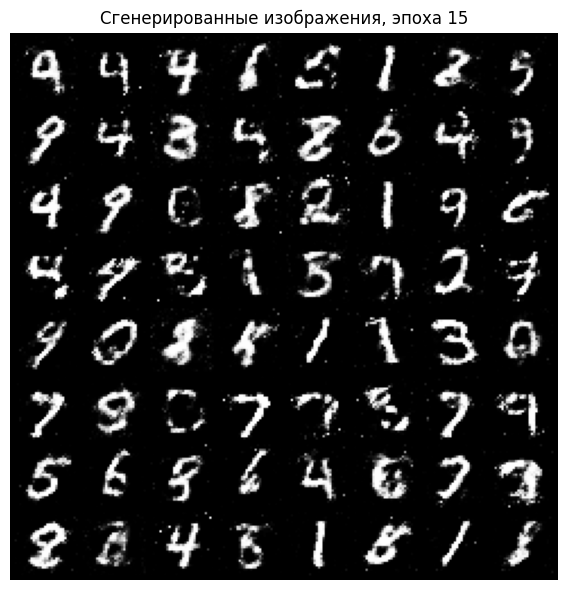

Эпоха 16/30 | loss_G=0.8310, loss_D=1.3106
Эпоха 17/30 | loss_G=0.8206, loss_D=1.3193
Эпоха 18/30 | loss_G=0.8136, loss_D=1.3218
Эпоха 19/30 | loss_G=0.8152, loss_D=1.3213
Эпоха 20/30 | loss_G=0.8090, loss_D=1.3245


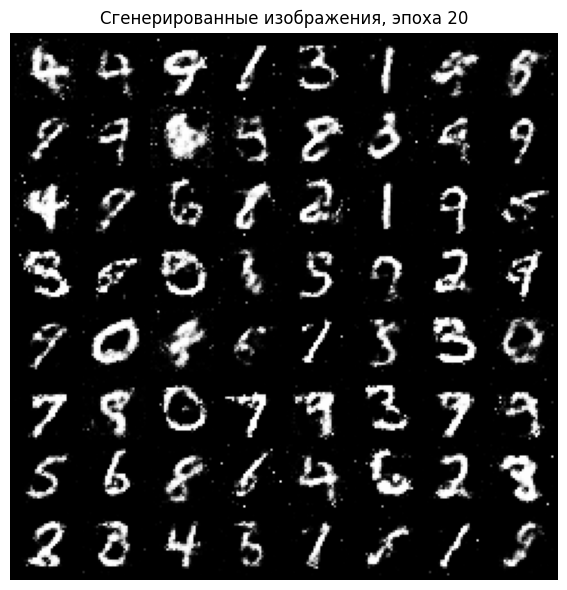

Эпоха 21/30 | loss_G=0.8085, loss_D=1.3262
Эпоха 22/30 | loss_G=0.7971, loss_D=1.3286
Эпоха 23/30 | loss_G=0.8038, loss_D=1.3274
Эпоха 24/30 | loss_G=0.7998, loss_D=1.3279
Эпоха 25/30 | loss_G=0.7983, loss_D=1.3281


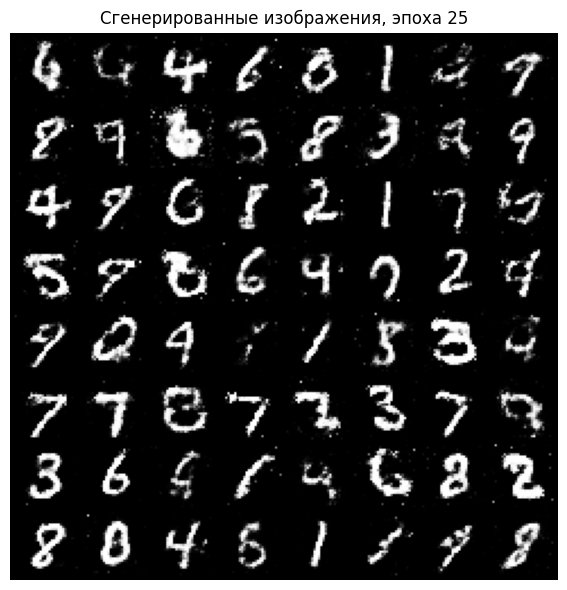

Эпоха 26/30 | loss_G=0.7966, loss_D=1.3304
Эпоха 27/30 | loss_G=0.7942, loss_D=1.3309
Эпоха 28/30 | loss_G=0.7971, loss_D=1.3294
Эпоха 29/30 | loss_G=0.7936, loss_D=1.3306
Эпоха 30/30 | loss_G=0.7909, loss_D=1.3327


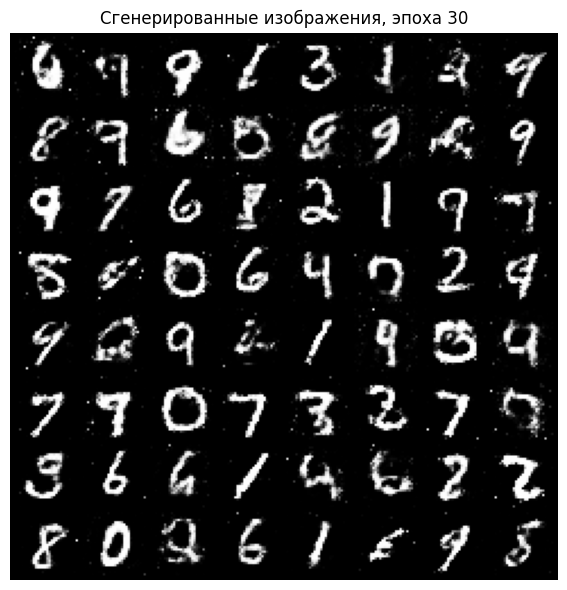

In [10]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 30  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

## 6. Графики лоссов генератора и дискриминатора

Посмотрим, как ведут себя лоссы G и D по эпохам.


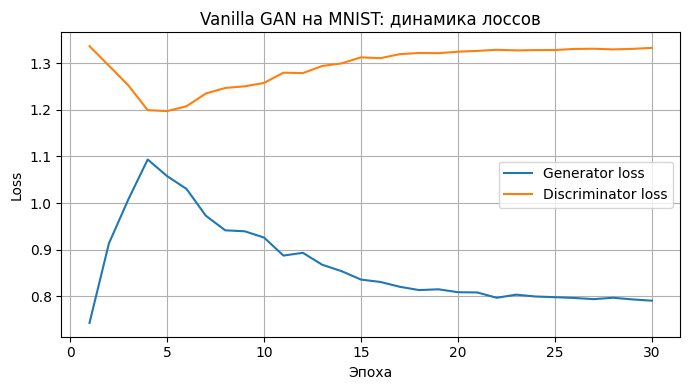

In [11]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ кривых лоссов

Опишите:
- есть ли тенденция к какому‑то «равновесию» между лоссами генератора и дискриминатора;  
- наблюдаются ли периодические колебания (кто «побеждает» на разных этапах обучения);  
- насколько реальное поведение лоссов совпало с вашими ожиданиями из раздела 1.


In [15]:
loss_comment = """1. К какому‑то равновесию лоссы действительно приближаются, оба держатся примерно около единицы, ни один не уходит в ноль и не взрывается. Это говорит, что генератор и дискриминатор в целом уравновешены и оба продолжают учиться.
2.В начале дискриминатор сильнее, его лосс ниже, а у генератора выше. Потом генератор учится лучше обманывать дискриминатор, лоссы сближаются и начинают колебаться вокруг некоторого уровня. Для GAN такие колебания нормальны, здесь нет гладкого убывания, как в обычной классификации.
3. Такое поведение в целом совпадает с ожиданиями. Я и ожидала, что лоссы не будут идти ровно вниз. По картинкам видно, что простые цифры вроде 9, 3, 1 и 7 получаются довольно четкими, а другие классы более размытые """
print(loss_comment)

1. К какому‑то равновесию лоссы действительно приближаются, оба держатся примерно около единицы, ни один не уходит в ноль и не взрывается. Это говорит, что генератор и дискриминатор в целом уравновешены и оба продолжают учиться.
2.В начале дискриминатор сильнее, его лосс ниже, а у генератора выше. Потом генератор учится лучше обманывать дискриминатор, лоссы сближаются и начинают колебаться вокруг некоторого уровня. Для GAN такие колебания нормальны, здесь нет гладкого убывания, как в обычной классификации.
3. Такое поведение в целом совпадает с ожиданиями. Я и ожидала, что лоссы не будут идти ровно вниз. По картинкам видно, что простые цифры вроде 9, 3, 1 и 7 получаются довольно четкими, а другие классы более размытые 


## 7. Финальная генерация изображений и визуальная оценка

Сгенерируем новые изображения из случайного шума и посмотрим, насколько они похожи на реальный MNIST.


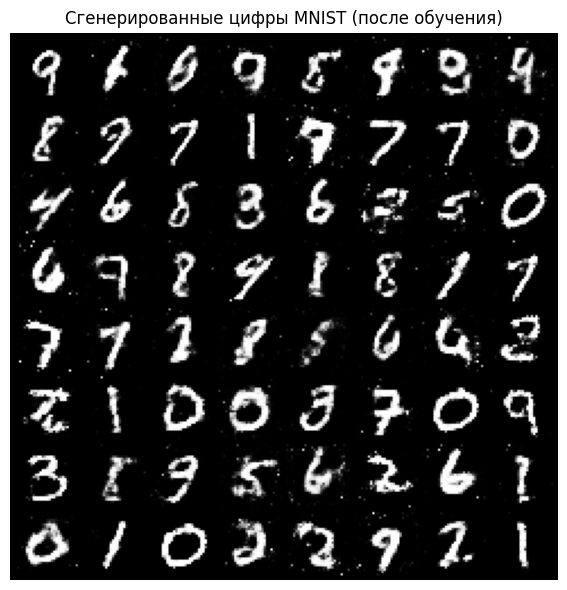

In [12]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

### Оценка качества сгенерированных цифр

Опишите:
- какие цифры получаются наиболее убедительными, а какие чаще всего выглядят как «шум» или гибриды;  
- встречаются ли явно «несуществующие» объекты, не похожие ни на одну цифру, и как часто;  
- как вы думаете, на что сильнее всего влияет качество: глубина сетей, размер `z_dim`, число эпох, баланс обучения G/D.


In [16]:
gen_quality_comment = """1. Наиболее убедительно выглядят цифры 1, 9 и 7, их форма чёткая и хорошо читается, они похожи на реальные примеры MNIST. Цифры 6, 5, 3, 0 и 4 чаще выглядят как шум или гибриды, у них размытые и странные контуры, из‑за этого сложнее понять, какая цифра имеется в виду.
2. Встречаются и явно несуществующие объекты, которые больше похожи на кляксу . Они появляются не в каждом примере, но достаточно регулярно среди сложных классов.
3. По ощущениям качество сильнее всего зависит от баланса обучения генератора и дискриминатора и от числа эпох. Архитектура и глубина сетей тоже важны, а размер z_dim влияет на разнообразие, но слишком маленькое или слишком большое значение может ухудшать результат."""
print(gen_quality_comment)

1. Наиболее убедительно выглядят цифры 1, 9 и 7, их форма чёткая и хорошо читается, они похожи на реальные примеры MNIST. Цифры 6, 5, 3, 0 и 4 чаще выглядят как шум или гибриды, у них размытые и странные контуры, из‑за этого сложнее понять, какая цифра имеется в виду.
2. Встречаются и явно несуществующие объекты, которые больше похожи на кляксу . Они появляются не в каждом примере, но достаточно регулярно среди сложных классов.
3. По ощущениям качество сильнее всего зависит от баланса обучения генератора и дискриминатора и от числа эпох. Архитектура и глубина сетей тоже важны, а размер z_dim влияет на разнообразие, но слишком маленькое или слишком большое значение может ухудшать результат.


## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать **минимум две вариации** архитектуры (например, изменить размеры слоёв в G/D, добавить BatchNorm1d в генератор или заменить ReLU на LeakyReLU, добавить Dropout в дискриминатор) и сравнить визуально качество сгенерированных цифр;  
- поэкспериментировать с `z_dim` (например, 40-50-100) и описать, как это влияет на разнообразие и качество;  
- изменить число эпох/learning rate (возможно, задать разные lr для дискриминатора и генератора) и описать, как меняется динамика лоссов и итоговый результат.

In [17]:
final_summary = """В работе сравнивались две конфигурации GAN на датасете MNIST. Исходная архитектура: генератор с тремя слоями 256, 512, 1024 с BatchNorm1d и LeakyReLU, дискриминатор с тремя слоями и Dropout(0.3). Моя вариация генератор углублен до четырех слое 512, 1024, 2048, 1024, дискриминатор получил дополнительный Dropout. В обоих случаях z_dim=100, lr_G=2e-4, lr_D=1e-4, 30 эпох.
Исходная архитектура обучалась стабильно, цифры становились узнаваемыми к 15–20 эпохе, однако часть оставалась размытой. В моем варианте поначалу сходилась медленнее,но к концу 30 эпох качество изображений оказалось чуть лучше, цифры выглядели более четкими и разнообразными. Дополнительный Dropout в дискриминаторе помог избежать его доминирования над генератором. Значение z_dim=100 в обоих вариантах обеспечивало достаточное разнообразие генерируемых цифр. При уменьшении z_dim до 40–50 разнообразие снижается и модель склонна генерировать похожие образцы, при увеличении сверх 100 прироста качества не наблюдается, но усложняется задача генератора.  Оптимальной оказалась моя вариация.
Генератор выигрывает от большей глубины и BatchNorm, дискриминатор не должен быть слишком сильным, поэтому Dropout и чуть меньший lr_D помогают удержать баланс. Значение z_dim в диапазоне 64–100 является хорошей отправной точкой для MNIST, а увеличение числа эпох до 50 заметно улучшает четкость ."""
print(final_summary)

В работе сравнивались две конфигурации GAN на датасете MNIST. Исходная архитектура: генератор с тремя слоями 256, 512, 1024 с BatchNorm1d и LeakyReLU, дискриминатор с тремя слоями и Dropout(0.3). Моя вариация генератор углублен до четырех слое 512, 1024, 2048, 1024, дискриминатор получил дополнительный Dropout. В обоих случаях z_dim=100, lr_G=2e-4, lr_D=1e-4, 30 эпох. 
Исходная архитектура обучалась стабильно, цифры становились узнаваемыми к 15–20 эпохе, однако часть оставалась размытой. В моем варианте поначалу сходилась медленнее,но к концу 30 эпох качество изображений оказалось чуть лучше, цифры выглядели более четкими и разнообразными. Дополнительный Dropout в дискриминаторе помог избежать его доминирования над генератором. Значение z_dim=100 в обоих вариантах обеспечивало достаточное разнообразие генерируемых цифр. При уменьшении z_dim до 40–50 разнообразие снижается и модель склонна генерировать похожие образцы, при увеличении сверх 100 прироста качества не наблюдается, но усложн